In [1]:
!hf auth login

User is already logged in. Use `hf auth login --force` to force re-login.


In [5]:
!pip install git+https://github.com/huggingface/transformers.git@v4.57.6

  Cloning https://github.com/huggingface/transformers.git (to revision v4.57.6) to /tmp/pip-req-build-e6niww64
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-e6niww64
  Running command git checkout -q 7dacdf4543ca4fe081f99dedacdb70d8df0fd366
  Resolved https://github.com/huggingface/transformers.git to commit 7dacdf4543ca4fe081f99dedacdb70d8df0fd366
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.6 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-4.57.6-py3-none-any.whl size=11993498 sha256=8b8d519329808b3110758787b2b5bf1cc6aa3c66bd1f275eb74cd8a9e19ee601
  Stored in directory: /tmp/pip-ephem-wheel-cache-em_7mkzf/wheels/3d/30/03/459a6cbd986dcc55e4f31298eebf7f7198e82ce375fc563b5a
Successfully built transformers
  Attempting uninstall: huggingfa

Number of attention heads from config: 12
Hidden size from config: 768
Head dimension: 64

Object DINO similarity applied. Layers processed: 12

=> Dynamically selected Cluster 2 as the primary object cluster.
=> Selections: [(8, [8]), (10, [2, 3, 6, 9]), (11, [0, 1, 2, 3, 6, 8, 9, 10])]


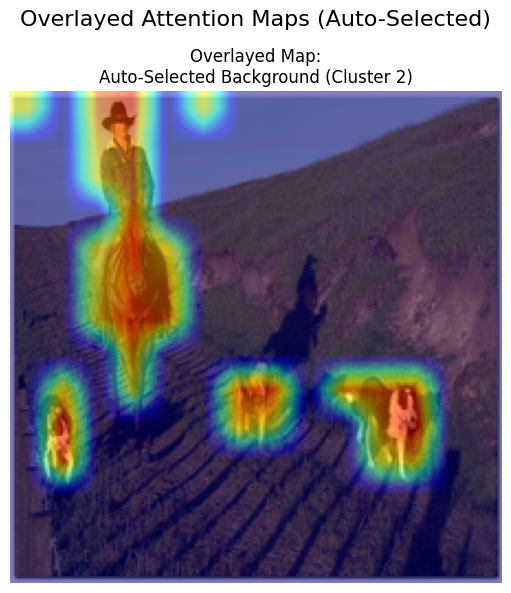

In [3]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

# =========================================================
# 1. Load Model & Processor
# =========================================================
pretrained_model_name = "facebook/dinov3-vitb16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(pretrained_model_name)
model.eval()
# model.cuda() # Uncomment if running on GPU

# Extract model configuration dynamically
num_heads = model.config.num_attention_heads
hidden_size = model.config.hidden_size
head_dim = hidden_size // num_heads

print(f"Number of attention heads from config: {num_heads}")
print(f"Hidden size from config: {hidden_size}")
print(f"Head dimension: {head_dim}")


# =========================================================
# 2. Load and Process Image
# =========================================================
img_path = "/content/test_image.jpg" # Change to your image path
image = Image.open(img_path).convert("RGB")
resize_size = (224, 224)
image_resized = image.resize(resize_size)
W, H = image_resized.size

inputs = processor(images=image_resized, return_tensors="pt").to(model.device)


# =========================================================
# 3. Bulletproof Hook setup for Q, K, V
# =========================================================
qkv_outputs = {}
hook_handles = []

# Dynamically locate transformer layers
if hasattr(model, "encoder") and hasattr(model.encoder, "layer"):
    transformer_layers = model.encoder.layer
elif hasattr(model, "model") and hasattr(model.model, "layer"):
    transformer_layers = model.model.layer
elif hasattr(model, "layer"):
    transformer_layers = model.layer
elif hasattr(model, "blocks"):
    transformer_layers = model.blocks
else:
    raise AttributeError("Could not dynamically locate transformer layers.")

def get_qkv_hook(layer_idx):
    def hook(module, input, output):
        hidden_states = input[0]

        if hasattr(module, "query") and hasattr(module, "key") and hasattr(module, "value"):
            q = module.query(hidden_states)
            k = module.key(hidden_states)
            v = module.value(hidden_states)
        elif hasattr(module, "qkv"):
            qkv = module.qkv(hidden_states)
            q, k, v = qkv.chunk(3, dim=-1)
        elif hasattr(module, "q_proj") and hasattr(module, "k_proj") and hasattr(module, "v_proj"):
            q = module.q_proj(hidden_states)
            k = module.k_proj(hidden_states)
            v = module.v_proj(hidden_states)
        else:
            raise AttributeError("Could not locate QKV projections.")

        qkv_outputs[layer_idx] = {
            'q': q.detach().cpu(),
            'k': k.detach().cpu(),
            'v': v.detach().cpu()
        }
    return hook

for i, layer in enumerate(transformer_layers):
    if hasattr(layer, "attention") and hasattr(layer.attention, "attention"):
        target_layer = layer.attention.attention
    elif hasattr(layer, "attention"):
        target_layer = layer.attention
    elif hasattr(layer, "attn"):
        target_layer = layer.attn
    else:
        target_layer = layer

    hook_handle = target_layer.register_forward_hook(get_qkv_hook(i))
    hook_handles.append(hook_handle)

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

for handle in hook_handles:
    handle.remove()


# =========================================================
# 4. Reshape Tensors & Remove Special Tokens (CLS + 4 Reg)
# =========================================================
N_patches = (W // model.config.patch_size) * (H // model.config.patch_size)

processed_qkv_by_layer = {}
for layer_idx, qkv_dict in qkv_outputs.items():
    q = qkv_dict['q'][:, 5:, :]
    k = qkv_dict['k'][:, 5:, :]
    v = qkv_dict['v'][:, 5:, :]

    q = q.reshape(1, N_patches, num_heads, head_dim).permute(0, 2, 1, 3)
    k = k.reshape(1, N_patches, num_heads, head_dim).permute(0, 2, 1, 3)
    v = v.reshape(1, N_patches, num_heads, head_dim).permute(0, 2, 1, 3)

    processed_qkv_by_layer[layer_idx] = {'q': q, 'k': k, 'v': v}


# =========================================================
# 5. Object DINO Similarity
# =========================================================
def object_dino_similarity(x: torch.Tensor, iters: int = 1, temp: float = None) -> torch.Tensor:
    d = x.size(-1)
    if temp is None:
        temp = d ** -0.5

    xs = x.clone()
    attn = None
    logits_before_temp = None
    for _ in range(iters):
        xs = F.normalize(xs, dim=-1)
        logits_before_temp = torch.einsum("bhid,bhjd->bhij", xs, xs)
        logits = logits_before_temp * temp
        attn = logits.softmax(dim=-1)
        xs = torch.einsum("bhij,bhjd->bhid", attn, xs)

    return attn, logits_before_temp

object_dino_similarities = {}
for layer_idx, tensors in processed_qkv_by_layer.items():
    attn_qq, _ = object_dino_similarity(tensors['q'])
    attn_kk, _ = object_dino_similarity(tensors['k'])
    attn_vv, _ = object_dino_similarity(tensors['v'])

    object_dino_similarities[layer_idx] = {
        'qq': attn_qq,
        'kk': attn_kk,
        'vv': attn_vv
    }
print(f"\nObject DINO similarity applied. Layers processed: {len(object_dino_similarities)}")


# =========================================================
# 6. KMeans Clustering of Attention Maps
# =========================================================
all_maps = []
map_labels = []
hf = wf = int((W // model.config.patch_size))

for layer_idx, attns in object_dino_similarities.items():
    attn = (attns["vv"] + attns["qq"] + attns["kk"]) / 3.0
    for head_idx in range(attn.shape[1]):
        attn_head = attn[0, head_idx]
        token_map = attn_head.mean(0)
        all_maps.append(token_map.flatten().cpu().numpy())
        map_labels.append((layer_idx, head_idx))

all_maps = np.array(all_maps)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(all_maps)

k_clusters = 5
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_scaled)

clusters = {i: [] for i in range(k_clusters)}
for idx, c in enumerate(cluster_ids):
    clusters[c].append(map_labels[idx])

formatted_clusters = {}
for c, items in clusters.items():
    layer_to_heads = defaultdict(list)
    for layer, head in items:
        layer_to_heads[layer].append(head)
    formatted_clusters[c] = [(layer, sorted(heads)) for layer, heads in sorted(layer_to_heads.items())]


# =========================================================
# 7. Auto-Select Primary Object Cluster
# =========================================================
num_layers = max(layer for layer, _ in map_labels)

best_cluster_id = None
max_heads = 0

for cluster_id, layers_heads in formatted_clusters.items():
    for layer, heads in layers_heads:
        if layer == num_layers and len(heads) > max_heads:
            max_heads = len(heads)
            best_cluster_id = cluster_id

if best_cluster_id is None:
    raise ValueError(f"No cluster found with heads from the final layer ({num_layers}).")

dynamic_selections = formatted_clusters[best_cluster_id]
print(f"\n=> Dynamically selected Cluster {best_cluster_id} as the primary object cluster.")
print(f"=> Selections: {dynamic_selections}")


# =========================================================
# 8. Generate Inverted Maps & Visualize
# =========================================================
def attn_to_patchmap_mixed(attns_by_layer, hf, wf, image, selections, prefix="mixed"):
    attn_list = []
    for (layer_idx, head_indices) in selections:
        attn_vv = attns_by_layer[layer_idx]["vv"]
        attn_qq = attns_by_layer[layer_idx]["qq"]
        attn_kk = attns_by_layer[layer_idx]["kk"]
        attn = (attn_vv + attn_qq + attn_kk) / 3.0

        if head_indices is None or len(head_indices) == 0:
            selected = attn[:, :].mean(1)
        else:
            selected = attn[:, head_indices].mean(1)
        attn_list.append(selected)

    attn_merged = torch.stack(attn_list).mean(0)
    token_map = attn_merged[0].mean(0)
    patch_corr = token_map.reshape(hf, wf)

    p_min, p_max = patch_corr.min(), patch_corr.max()
    patch_corr = (patch_corr - p_min) / (p_max - p_min + 1e-6)

    # Calculate Inverse Map (Background)
    patch_corr_inv = 1.0 - patch_corr
    threshold = 0.6
    patch_corr_inv = torch.where(patch_corr_inv >= threshold, patch_corr_inv, torch.tensor(0.0, device=patch_corr_inv.device))

    patch_map_resized_inv = np.array(
        Image.fromarray((patch_corr_inv.cpu().numpy() * 255).astype(np.uint8))
        .resize(image.size, resample=Image.BILINEAR)
    )

    name = f"{prefix} Background (Cluster {best_cluster_id})"

    # Return ONLY the inverted map
    return {
        name: patch_map_resized_inv
    }

auto_mix = attn_to_patchmap_mixed(
    object_dino_similarities, hf, wf, image_resized,
    selections=dynamic_selections,
    prefix="Auto-Selected"
)

# Plotting - Overlayed ONLY
all_maps = {**auto_mix}
n_maps = len(all_maps)
n_cols = max(1, min(2, n_maps))
n_rows = int(np.ceil(n_maps / n_cols))

fig_overlay, axes_overlay = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes_overlay = np.atleast_1d(axes_overlay).flatten()

for ax, (name, heatmap) in zip(axes_overlay, all_maps.items()):
    ax.imshow(image_resized)
    ax.imshow(heatmap, cmap="jet", alpha=0.5)
    ax.set_title(f"Overlayed Map:\n{name}")
    ax.axis("off")

for i in range(len(all_maps), len(axes_overlay)):
    axes_overlay[i].axis("off")
fig_overlay.suptitle("Overlayed Attention Maps (Auto-Selected)", fontsize=16)
plt.tight_layout()

plt.show()